<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/ML_Regression/MiniProject4_Employee_Attrition_Prediction_Stan_Ver_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini Project Notebook: Employee Attrition Prediction

## **Note:** This notebook is part of an in-house Kaggle competition

## Problem Statement

To predict employee attrition using CatBoost and XgBoost

## Learning Objectives

At the end of the experiment, you will be able to

* explore the employee attrition dataset
* apply CatBoost and XgBoost on the dataset
* tune the model hyperparameters to improve accuracy
* evaluate the model using suitable metrics


## Introduction

Employee attrition is the gradual reduction in employee numbers. Employee attrition happens when the size of your workforce diminishes over time. This means that employees are leaving faster than they are hired. Employee attrition happens when employees retire, resign, or simply aren't replaced.
Although employee attrition can be company-wide, it may also be confined to specific parts of a business.

Employee attrition can happen for several reasons. These include unhappiness about employee benefits or the pay structure, a lack of employee development opportunities, and even poor conditions in the workplace.

To know more about the factors that lead to employee attrition, refer [here](https://www.betterup.com/blog/employee-attrition#:~:text=Employee%20attrition%20is%20the%20gradual,or%20simply%20aren't%20replaced).


**Gradient Boosted Decision Trees**

* Gradient boosted decision trees (GBDTs) are one of the most important machine learning models.

* GBDTs originate from AdaBoost, an algorithm that ensembles weak learners and uses the majority vote, weighted by their individual accuracy, to solve binary classification problems. The weak learners in this case are decision trees with a single split, called decision stumps.

* Some of the widely used gradient boosted decision trees are XgBoost, CatBoost and LightGBM.

## Dataset

The dataset used for this mini-project is [HR Employee Attrition dataset](https://data.world/aaizemberg/hr-employee-attrition). This dataset is synthetically created by IBM data scientists. There are 35 features and 1470 records.

There are numerical features such as:

* Age
* DistanceFromHome
* EmployeeNumber
* PerformanceRating

There are several categorical features such as:
* JobRole
* EducationField
* Department
* BusinessTravel

Dependent or target feature is 'attrition' which has values as Yes/No.

### **Kaggle Competition**

Please refer to the link for viewing the
[Kaggle Competition Document](https://drive.google.com/file/d/1YNYJR8iXuvmEgAZQYNmBpGQbc66Lkwnq/view?usp=sharing) and join the Kaggle Competition using the hyperlink given in this document under '*Kaggle* Competition site'.

## Grading = 10 Points

In [ ]:
#@title Download the data
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/hr_employee_attrition_train.csv
print("Data Downloaded Successfuly!!")

Data Downloaded Successfuly!!


### Install CatBoost

In [ ]:
!pip -qq install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 4.2 MB/s eta 0:00:00


### Import Required Packages

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, metrics
import warnings
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 100)
%matplotlib inline

## Load the Dataset

**Exercise 1: Read the dataset [0.5 Mark]**

**Hint:** pd.read_csv()

In [ ]:
# read the dataset
# YOUR CODE HERE
dfAttritionData = pd.read_csv('hr_employee_attrition_train.csv')

In [ ]:
# Check the shape of dataframe.
# YOUR CODE HERE
dfAttritionData.shape

(1170, 35)

### STAN To-Do: Check whether remaining 300 records are in Test

There can be more than one file to read as this is introduced as a competition, dataset has one file for training the model. Their can be other files as one containing the test features and the other can be the true labels.

## Data Exploration

- Check for missing values
- Check for consistent data type across a feature
- Check for outliers or inconsistencies in data columns
- Check for correlated features
- Do we have a target label imbalance
- How our independent variables are distributed relative to our target label
- Are there features that have strong linear or monotonic relationships? Making correlation heatmaps makes it easy to identify possible collinearity

**Checking for null values**

In [ ]:
dfAttritionData.isnull().sum()

age                         0
businesstravel              0
dailyrate                   0
department                  0
distancefromhome            0
education                   0
educationfield              0
employeecount               0
employeenumber              0
environmentsatisfaction     0
gender                      0
hourlyrate                  0
jobinvolvement              0
joblevel                    0
jobrole                     0
jobsatisfaction             0
maritalstatus               0
monthlyincome               0
monthlyrate                 0
numcompaniesworked          0
over18                      0
overtime                    0
percentsalaryhike           0
performancerating           0
relationshipsatisfaction    0
standardhours               0
stockoptionlevel            0
totalworkingyears           0
trainingtimeslastyear       0
worklifebalance             0
yearsatcompany              0
yearsincurrentrole          0
yearssincelastpromotion     0
yearswithc

**No NULL values found in the dataset.**

**Exercise 2: Create a `List` of numerical and categorical columns. Display a statistical description of the dataset. Remove missing values (if any) [0.5 Mark]**

In [ ]:
dfAttritionData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       1170 non-null   int64 
 1   businesstravel            1170 non-null   object
 2   dailyrate                 1170 non-null   int64 
 3   department                1170 non-null   object
 4   distancefromhome          1170 non-null   int64 
 5   education                 1170 non-null   int64 
 6   educationfield            1170 non-null   object
 7   employeecount             1170 non-null   int64 
 8   employeenumber            1170 non-null   int64 
 9   environmentsatisfaction   1170 non-null   int64 
 10  gender                    1170 non-null   object
 11  hourlyrate                1170 non-null   int64 
 12  jobinvolvement            1170 non-null   int64 
 13  joblevel                  1170 non-null   int64 
 14  jobrole                 

**Hint:** Use `for` to iterate through each column.

In [ ]:
# YOUR CODE HERE
#dfAttritionData.info()
categoricalColumns = []
numericalColumns = []
likelyCategoricalColumns = []
for column in dfAttritionData.columns:
    # Check if column is numeric
    if pd.api.types.is_numeric_dtype(dfAttritionData[column]):
        # Apply heuristic for categorical: if unique values are less than 10% of total values, consider it categorical
        if dfAttritionData[column].nunique() / len(dfAttritionData[column]) < 0.1:
            #print(f'Column {column} is numeric but likely categorical')
            likelyCategoricalColumns.append(column)
        else:
            #print(f'Column {column} is numerical')
            numericalColumns.append(column)
    else:
        #print(f'Column {column} is categorical')
        categoricalColumns.append(column)
print(f'Numerical Columns: {numericalColumns}')
print(f'Categorical Columns: {categoricalColumns}')
print(f'Likely Categorical Columns: {likelyCategoricalColumns}')

Numerical Columns: ['dailyrate', 'employeenumber', 'monthlyincome', 'monthlyrate']
Categorical Columns: ['businesstravel', 'department', 'educationfield', 'gender', 'jobrole', 'maritalstatus', 'over18', 'overtime', 'attrition']
Likely Categorical Columns: ['age', 'distancefromhome', 'education', 'employeecount', 'environmentsatisfaction', 'hourlyrate', 'jobinvolvement', 'joblevel', 'jobsatisfaction', 'numcompaniesworked', 'percentsalaryhike', 'performancerating', 'relationshipsatisfaction', 'standardhours', 'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearsincurrentrole', 'yearssincelastpromotion', 'yearswithcurrmanager']


In [ ]:
dfAttritionData["age"].value_counts()
sAge = dfAttritionData["age"].value_counts()
for index, value in sAge.items():
    print(f"{index}, {value}", end='; ')

34, 66; 35, 64; 29, 57; 31, 56; 30, 52; 33, 51; 36, 50; 32, 46; 37, 42; 40, 41; 28, 41; 38, 37; 27, 36; 42, 36; 39, 33; 45, 31; 41, 30; 26, 30; 43, 28; 44, 26; 46, 25; 50, 24; 24, 22; 49, 19; 47, 18; 48, 18; 25, 18; 55, 16; 53, 16; 51, 15; 52, 15; 23, 13; 54, 13; 58, 13; 22, 12; 56, 12; 21, 11; 20, 9; 18, 8; 59, 7; 19, 5; 57, 4; 60, 4; 

**Choosing to keep age as numerical to help to see value-based correlation in regression.**

In [ ]:
numericalColumns.append('age')

In [ ]:
sDist = dfAttritionData["distancefromhome"].value_counts()
#sDist = sDist.sort_index(inplace=True)
for index, value in sDist.items():
    print(f"{index}, {value}", end='; ')

1, 171; 2, 157; 7, 70; 10, 70; 3, 67; 8, 66; 9, 64; 5, 54; 6, 53; 4, 45; 16, 24; 24, 24; 25, 23; 15, 22; 29, 22; 18, 21; 11, 20; 28, 19; 23, 19; 12, 18; 26, 18; 19, 18; 21, 18; 17, 18; 22, 17; 20, 15; 14, 14; 13, 13; 27, 10; 

**Choosing to keep distancefromhome as numerical to help to see value-based correlation in regression.**

In [ ]:
numericalColumns.append('distancefromhome')

In [ ]:
sEdu = dfAttritionData["education"].value_counts()
#sDist = sDist.sort_index(inplace=True)
for index, value in sEdu.items():
    print(f"{index}, {value}", end='; ')

3, 473; 4, 305; 2, 223; 1, 129; 5, 40; 

**education can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**

In [ ]:
categoricalColumns.append('education')

In [ ]:
sEmpCnt = dfAttritionData["employeecount"].value_counts()
#sDist = sDist.sort_index(inplace=True)
for index, value in sEmpCnt.items():
    print(f"{index}, {value}", end='; ')

1, 1170; 

**This column can be deleted as it just has one value across all samples.**

In [ ]:
dfAttritionData.drop("employeecount", axis=1, inplace = True)

In [ ]:
sEnvSat = dfAttritionData["environmentsatisfaction"].value_counts()
for index, value in sEnvSat.items():
    print(f"{index}, {value}", end='; ')

3, 364; 4, 356; 1, 229; 2, 221; 

**environmentsatisfaction can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**


In [ ]:
categoricalColumns.append('environmentsatisfcation')

In [ ]:
sHrRate = dfAttritionData["hourlyrate"].value_counts()
for index, value in sHrRate.items():
    print(f"{index}, {value}", end='; ')

96, 25; 66, 25; 42, 25; 72, 24; 79, 24; 84, 23; 57, 22; 48, 22; 78, 21; 54, 21; 43, 20; 45, 20; 32, 20; 56, 20; 46, 20; 98, 20; 83, 20; 52, 19; 95, 19; 51, 19; 87, 18; 59, 18; 80, 18; 82, 17; 64, 17; 97, 17; 67, 17; 73, 17; 77, 17; 60, 17; 62, 17; 76, 16; 94, 16; 92, 16; 75, 16; 65, 16; 37, 16; 33, 16; 71, 16; 44, 16; 36, 16; 40, 16; 49, 15; 58, 15; 88, 15; 91, 15; 41, 15; 99, 15; 86, 15; 30, 15; 74, 15; 61, 14; 81, 14; 63, 14; 50, 14; 90, 14; 100, 14; 35, 14; 55, 13; 93, 13; 89, 13; 38, 13; 70, 12; 31, 12; 39, 12; 69, 12; 85, 11; 34, 9; 47, 8; 68, 7; 53, 7; 

**Choosing to keep hourlyrate as numerical to help to see value-based correlation in regression.**

In [ ]:
numericalColumns.append('hourlyrate')

In [ ]:
sJobInv = dfAttritionData["jobinvolvement"].value_counts()
for index, value in sJobInv.items():
    print(f"{index}, {value}", end='; ')

3, 698; 2, 294; 4, 118; 1, 60; 

**jobinvolvement can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**

In [ ]:
categoricalColumns.append("jobinvolvement")

In [ ]:
sJobLevel = dfAttritionData["joblevel"].value_counts()
for index, value in sJobLevel.items():
    print(f"{index}, {value}", end='; ')

1, 442; 2, 412; 3, 181; 4, 86; 5, 49; 

**joblevel can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**



In [ ]:
categoricalColumns.append("joblevel")

In [ ]:
sJobSat = dfAttritionData["jobsatisfaction"].value_counts()
for index, value in sJobSat.items():
    print(f"{index}, {value}", end='; ')

4, 363; 3, 352; 1, 232; 2, 223; 

In [ ]:
categoricalColumns.append("jobsatisfaction")

**jobsatisfaction can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**



'numcompaniesworked', 'percentsalaryhike', 'performancerating', 'relationshipsatisfaction', 'standardhours', 'stockoptionlevel', 'totalworkingyears', 'trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearsincurrentrole', 'yearssincelastpromotion', 'yearswithcurrmanager']

In [ ]:
sNumComp = dfAttritionData["numcompaniesworked"].value_counts()
for index, value in sNumComp.items():
    print(f"{index}, {value}", end='; ')

1, 399; 0, 156; 3, 128; 2, 121; 4, 110; 7, 60; 6, 59; 5, 54; 9, 45; 8, 38; 

**numcompaniesworked can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**

In [ ]:
categoricalColumns.append("numcompaniesworked")

In [ ]:
sPercentHike = dfAttritionData["percentsalaryhike"].value_counts()
for index, value in sPercentHike.items():
    print(f"{index}, {value}", end='; ')

11, 172; 13, 166; 12, 159; 14, 157; 15, 76; 18, 72; 17, 64; 16, 64; 19, 60; 22, 47; 21, 42; 20, 37; 23, 22; 24, 17; 25, 15; 

**percentsalaryhike can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**

In [ ]:
categoricalColumns.append("percentsalaryhike")

In [ ]:
sPerfRating = dfAttritionData["performancerating"].value_counts()
for index, value in sPerfRating.items():
    print(f"{index}, {value}", end='; ')

3, 990; 4, 180; 

In [ ]:
categoricalColumns.append("performancerating")

**performancerating can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**

In [ ]:
sRelSat = dfAttritionData["relationshipsatisfaction"].value_counts()
for index, value in sRelSat.items():
    print(f"{index}, {value}", end='; ')

3, 378; 4, 350; 2, 229; 1, 213; 

**relationshipsatisfaction can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**

In [ ]:
categoricalColumns.append("relationshipsatisfaction")

In [ ]:
sStdHrs = dfAttritionData["standardhours"].value_counts()
for index, value in sStdHrs.items():
    print(f"{index}, {value}", end='; ')

80, 1170; 

**standardhours column has same value across all rows. So this can be deleted.**



In [ ]:
dfAttritionData.drop("standardhours", axis=1, inplace = True)

In [ ]:
sStockLevel = dfAttritionData["stockoptionlevel"].value_counts()
for index, value in sStockLevel.items():
    print(f"{index}, {value}", end='; ')

0, 504; 1, 481; 2, 117; 3, 68; 

**stockoptionlevel can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**



In [ ]:
categoricalColumns.append("stockoptionlevel")

In [ ]:
sWorkYrs = dfAttritionData["totalworkingyears"].value_counts()
for index, value in sWorkYrs.items():
    print(f"{index}, {value}", end='; ')

10, 148; 6, 98; 8, 86; 9, 73; 7, 70; 5, 69; 1, 62; 4, 53; 12, 39; 15, 35; 3, 33; 16, 32; 13, 30; 11, 28; 2, 27; 20, 26; 17, 26; 18, 23; 14, 22; 21, 21; 22, 20; 19, 18; 24, 14; 25, 13; 23, 13; 26, 11; 0, 10; 29, 10; 28, 10; 32, 9; 31, 7; 33, 6; 30, 5; 34, 5; 27, 5; 37, 4; 36, 4; 40, 2; 35, 2; 38, 1; 

**Choosing to keep totalworkingyears as numerical to help to see value-based correlation in regression.**

In [ ]:
numericalColumns.append("totalworkingyears")

trainingtimeslastyear', 'worklifebalance', 'yearsatcompany', 'yearsincurrentrole', 'yearssincelastpromotion', 'yearswithcurrmanager']

In [ ]:
sTrainTimes = dfAttritionData["trainingtimeslastyear"].value_counts()
for index, value in sTrainTimes.items():
    print(f"{index}, {value}", end='; ')

2, 430; 3, 388; 5, 104; 4, 98; 6, 56; 1, 54; 0, 40; 

**trainingtimeslastyear can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**

In [ ]:
categoricalColumns.append("trainingtimeslastyear")

In [ ]:
sWLBal = dfAttritionData["worklifebalance"].value_counts()
for index, value in sWLBal.items():
    print(f"{index}, {value}", end='; ')

3, 697; 2, 282; 4, 122; 1, 69; 

**worklifebalance can be retained as a categorical variable, as its count of distinct values clearly indicate categorization.**

In [ ]:
categoricalColumns.append("worklifebalance")

In [ ]:
sYrsComp = dfAttritionData["yearsatcompany"].value_counts()
for index, value in sYrsComp.items():
    print(f"{index}, {value}", end='; ')

5, 155; 1, 140; 2, 106; 3, 102; 4, 86; 10, 84; 7, 78; 8, 66; 9, 60; 6, 58; 0, 41; 11, 23; 20, 22; 13, 19; 15, 18; 14, 14; 22, 12; 18, 11; 12, 10; 19, 9; 16, 9; 21, 8; 17, 7; 33, 5; 26, 4; 25, 4; 24, 3; 32, 3; 29, 2; 27, 2; 31, 2; 23, 2; 40, 1; 36, 1; 34, 1; 37, 1; 30, 1; 

**Choosing to keep yearsatcompany as numerical to help to see value-based correlation in regression.**

In [ ]:
numericalColumns.append("yearsatcompany")

In [ ]:
sYrsInRole = dfAttritionData["yearsincurrentrole"].value_counts()
for index, value in sYrsInRole.items():
    print(f"{index}, {value}", end='; ')

2, 300; 0, 198; 7, 174; 3, 111; 4, 82; 8, 64; 9, 54; 1, 47; 6, 30; 5, 26; 10, 23; 11, 15; 13, 11; 14, 10; 12, 8; 15, 7; 16, 5; 17, 3; 18, 2; 

**Choosing to keep yearsincurrentrole as numerical to help to see value-based correlation in regression.**

In [ ]:
numericalColumns.append("yearsincurrentrole")

In [ ]:
sYrsSincePromo = dfAttritionData["yearssincelastpromotion"].value_counts()
for index, value in sYrsSincePromo.items():
    print(f"{index}, {value}", end='; ')

0, 481; 1, 272; 2, 124; 7, 61; 4, 46; 3, 44; 5, 35; 6, 26; 11, 16; 8, 15; 9, 11; 15, 10; 13, 9; 14, 8; 12, 7; 10, 5; 

**Choosing to keep yearssincelastpromotion as numerical to help to see value-based correlation in regression.**

In [ ]:
numericalColumns.append("yearssincelastpromotion")

In [ ]:
sYrsCurrMgr = dfAttritionData["yearswithcurrmanager"].value_counts()
for index, value in sYrsCurrMgr.items():
    print(f"{index}, {value}", end='; ')

2, 280; 0, 218; 7, 174; 3, 106; 8, 82; 4, 78; 1, 62; 9, 48; 10, 22; 5, 22; 6, 21; 12, 16; 11, 16; 13, 9; 17, 7; 15, 4; 14, 3; 16, 2; 

**Choosing to keep yearssincelastpromotion as numerical to help to see value-based correlation in regression.**

In [ ]:
numericalColumns.append("yearswithcurrmanager")

In [ ]:
categoricalColumns

['businesstravel',
 'department',
 'educationfield',
 'gender',
 'jobrole',
 'maritalstatus',
 'over18',
 'overtime',
 'attrition',
 'education',
 'environmentsatisfcation',
 'jobinvolvement',
 'joblevel',
 'jobsatisfaction',
 'numcompaniesworked',
 'percentsalaryhike',
 'performancerating',
 'relationshipsatisfaction',
 'stockoptionlevel',
 'trainingtimeslastyear',
 'worklifebalance']

In [ ]:
len(categoricalColumns)

21

In [ ]:
numericalColumns

['dailyrate',
 'employeenumber',
 'monthlyincome',
 'monthlyrate',
 'age',
 'distancefromhome',
 'hourlyrate',
 'totalworkingyears',
 'yearsatcompany',
 'yearsincurrentrole',
 'yearssincelastpromotion',
 'yearswithcurrmanager']

In [ ]:
len(numericalColumns)

12

In [ ]:
dfAttritionData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       1170 non-null   int64 
 1   businesstravel            1170 non-null   object
 2   dailyrate                 1170 non-null   int64 
 3   department                1170 non-null   object
 4   distancefromhome          1170 non-null   int64 
 5   education                 1170 non-null   int64 
 6   educationfield            1170 non-null   object
 7   employeenumber            1170 non-null   int64 
 8   environmentsatisfaction   1170 non-null   int64 
 9   gender                    1170 non-null   object
 10  hourlyrate                1170 non-null   int64 
 11  jobinvolvement            1170 non-null   int64 
 12  joblevel                  1170 non-null   int64 
 13  jobrole                   1170 non-null   object
 14  jobsatisfaction         

In [ ]:
dfAttritionData.describe()

,age,dailyrate,distancefromhome,education,employeenumber,environmentsatisfaction,hourlyrate,jobinvolvement,joblevel,jobsatisfaction,monthlyincome,monthlyrate,numcompaniesworked,percentsalaryhike,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
count,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.000000,1170.00000,1170.000000,1170.000000
mean,36.858120,797.822222,9.262393,2.917949,1021.113675,2.723932,65.501709,2.747009,2.049573,2.723077,6456.937607,14411.584615,2.750427,15.204274,3.153846,2.739316,0.785470,11.315385,2.842735,2.745299,6.925641,4.17094,2.138462,4.061538
std,9.183448,403.592661,8.150868,1.011534,600.548289,1.095847,20.310054,0.702625,1.096352,1.103799,4660.476506,7078.167743,2.521952,3.688952,0.360955,1.075225,0.847253,7.879363,1.306385,0.718864,6.232076,3.62788,3.201738,3.586350
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,0.000000
25%,30.000000,461.000000,2.000000,2.000000,496.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2914.750000,8387.500000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.00000,0.000000,2.000000
50%,35.000000,798.000000,7.000000,3.000000,1008.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4903.500000,14536.000000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.00000,1.000000,3.000000
75%,43.000000,1146.750000,14.000000,4.000000,1548.500000,4.000000,83.000000,3.000000,3.000000,4.000000,8215.250000,20456.250000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.00000,2.750000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,2065.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.00000,15.000000,17.000000


First, we want to get a sense of our data:
- What features have the most divergent distributions based on target class
- Do we have a target label imbalance
- How our independent variables are distributed relative to our target label
- Are there features that have strong linear or monotonic relationships, making correlation heatmaps makes it easy to identify possible colinearity

**STAN TO-DO: Need to decide on what to capture for "What features have the most divergent distributions based on target class"**

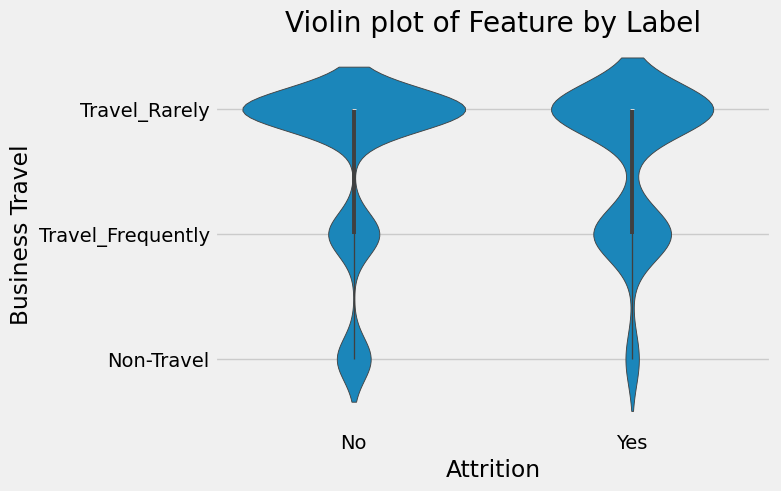

In [ ]:
sns.violinplot(x='attrition', y='businesstravel', data=dfAttritionData)

# Adding titles and labels (optional but recommended for clarity)
plt.title('Violin plot of Feature by Label')
plt.xlabel('Attrition')
plt.ylabel('Business Travel')

plt.show()

**Checking for Target Label imbalance**

In [ ]:
dfAttritionData["attrition"].value_counts()

No     981
Yes    189
Name: attrition, dtype: int64

**Clearly there is a target label imbalance.**

### Check for outliers

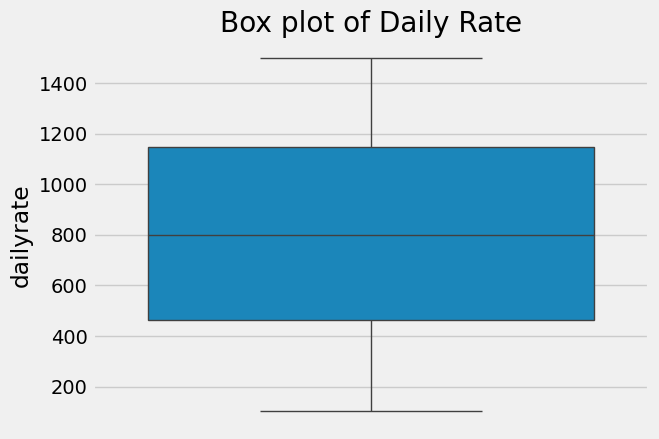

In [ ]:
# Creating a box plot
sns.boxplot(y=dfAttritionData['dailyrate'])

# Adding a title for clarity
plt.title('Box plot of Daily Rate')

plt.show()

**Exercise 3: Create a box plot to check for outliers [0.5 Mark]**

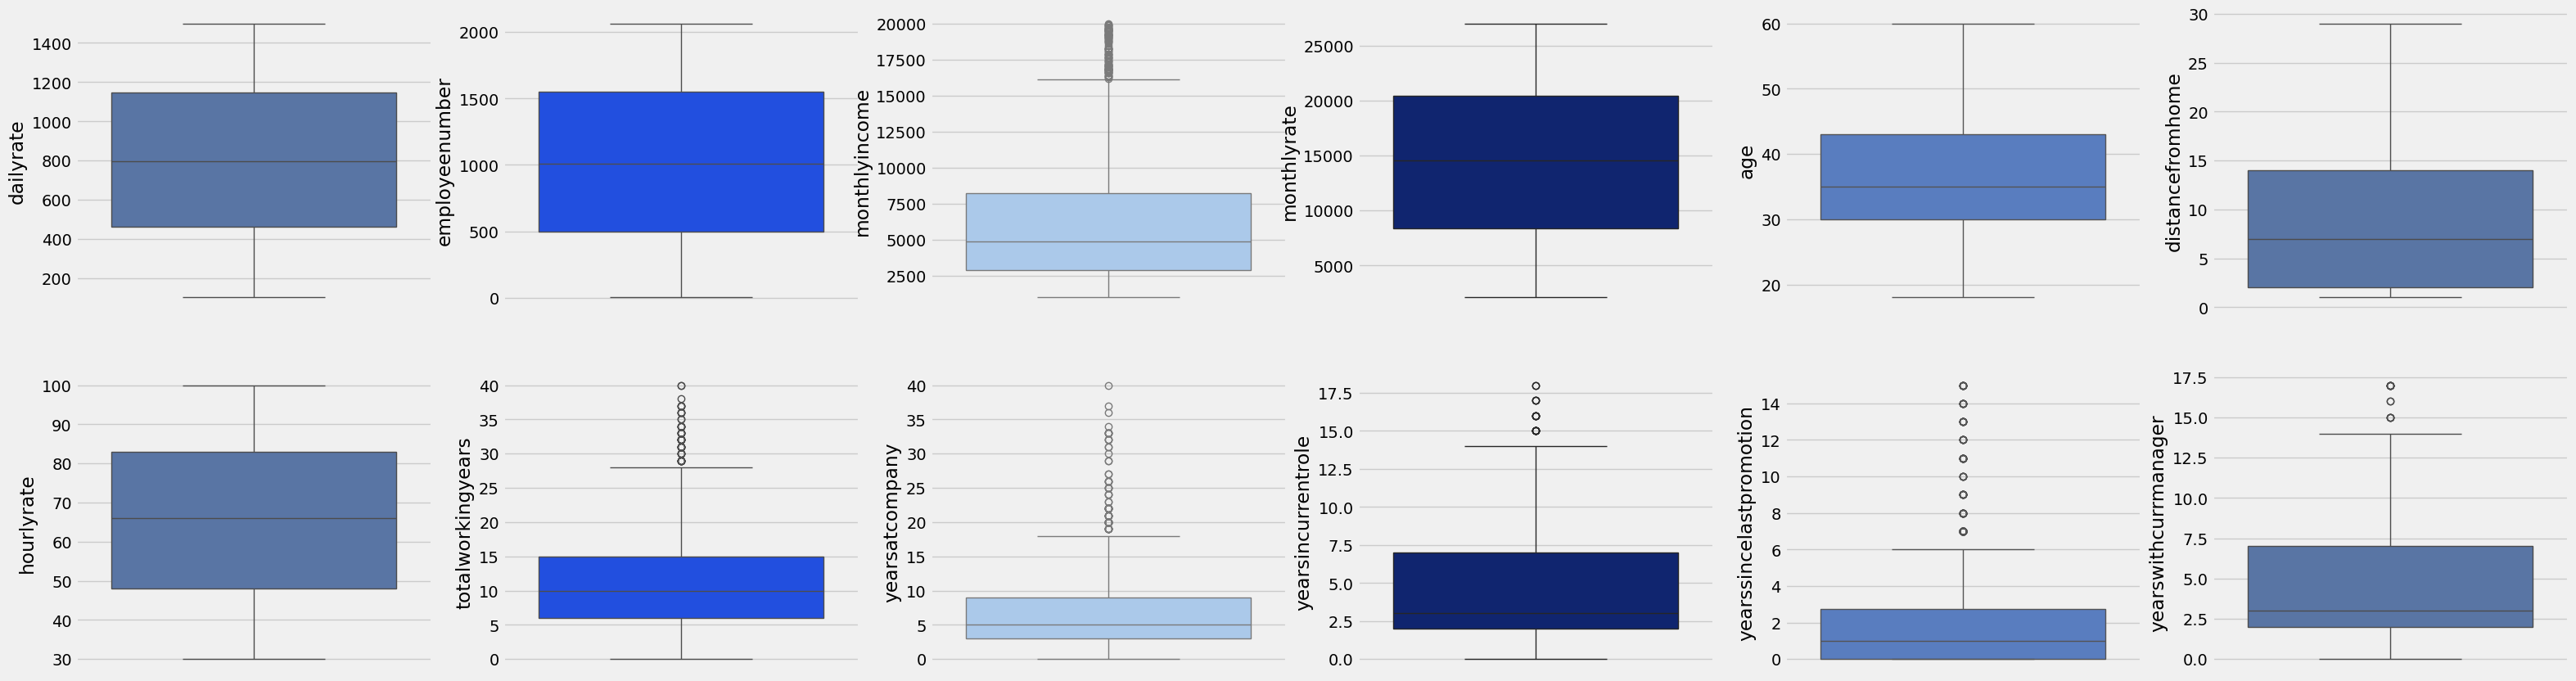

In [ ]:
# Check for outliers
# YOUR CODE HERE
plt.figure(figsize=(35, 10))
plt.subplot(2,6,1)
sns.boxplot(y = 'dailyrate', data = dfAttritionData, palette="deep")
plt.subplot(2,6,2)
sns.boxplot(y = 'employeenumber', data = dfAttritionData, palette="bright")
plt.subplot(2,6,3)
sns.boxplot(y = 'monthlyincome', data = dfAttritionData, palette="pastel")
plt.subplot(2,6,4)
sns.boxplot(y = 'monthlyrate', data = dfAttritionData, palette="dark")
plt.subplot(2,6,5)
sns.boxplot(y = 'age', data = dfAttritionData, palette="muted")
plt.subplot(2,6,6)
sns.boxplot(y = 'distancefromhome', data = dfAttritionData, palette="deep")
plt.subplot(2,6,7)
sns.boxplot(y = 'hourlyrate', data = dfAttritionData, palette="deep")
plt.subplot(2,6,8)
sns.boxplot(y = 'totalworkingyears', data = dfAttritionData, palette="bright")
plt.subplot(2,6,9)
sns.boxplot(y = 'yearsatcompany', data = dfAttritionData, palette="pastel")
plt.subplot(2,6,10)
sns.boxplot(y = 'yearsincurrentrole', data = dfAttritionData, palette="dark")
plt.subplot(2,6,11)
sns.boxplot(y = 'yearssincelastpromotion', data = dfAttritionData, palette="muted")
plt.subplot(2,6,12)
sns.boxplot(y = 'yearswithcurrmanager', data = dfAttritionData, palette="deep")
plt.show()

dailyrate',
 'employeenumber',
 'monthlyincome',
 'monthlyrate',
 'age',
 'distancefromhome',
 'hourlyrate',
 'totalworkingyears',
 'yearsatcompany',
 'yearsincurrentrole',
 'yearssincelastpromotion',
 'yearswithcurrmgr']


### Handling outliers

**Exercise 4: Use lower bound as 25% and upper bound as 75% to handle the outliers [0.5 Mark]**

In [ ]:
# YOUR CODE HERE
# Handing outliers
outlier_columns_list = ['monthlyincome', 'totalworkingyears', 'yearsatcompany', 'yearsincurrentrole', 'yearssincelastpromotion','yearswithcurrmanager']
df1 = dfAttritionData.copy()

def handle_outliers(df, outlier_column):
    '''Change the values of outlier to upper and lower whisker values '''
    q1 = df.describe()[outlier_column].loc["25%"]
    q3 = df.describe()[outlier_column].loc["75%"]
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    for i in range(len(df)):
        if df.loc[i,outlier_column] > upper_bound:
            df.loc[i,outlier_column]= upper_bound
        if df.loc[i,outlier_column] < lower_bound:
            df.loc[i,outlier_column]= lower_bound
    return df

for out_col in outlier_columns_list:
    df1 = handle_outliers(df1, out_col)

In [ ]:
# Recheck for outliers
# YOUR CODE HERE

In [ ]:
dfAttritionDataTrim = df1.copy()

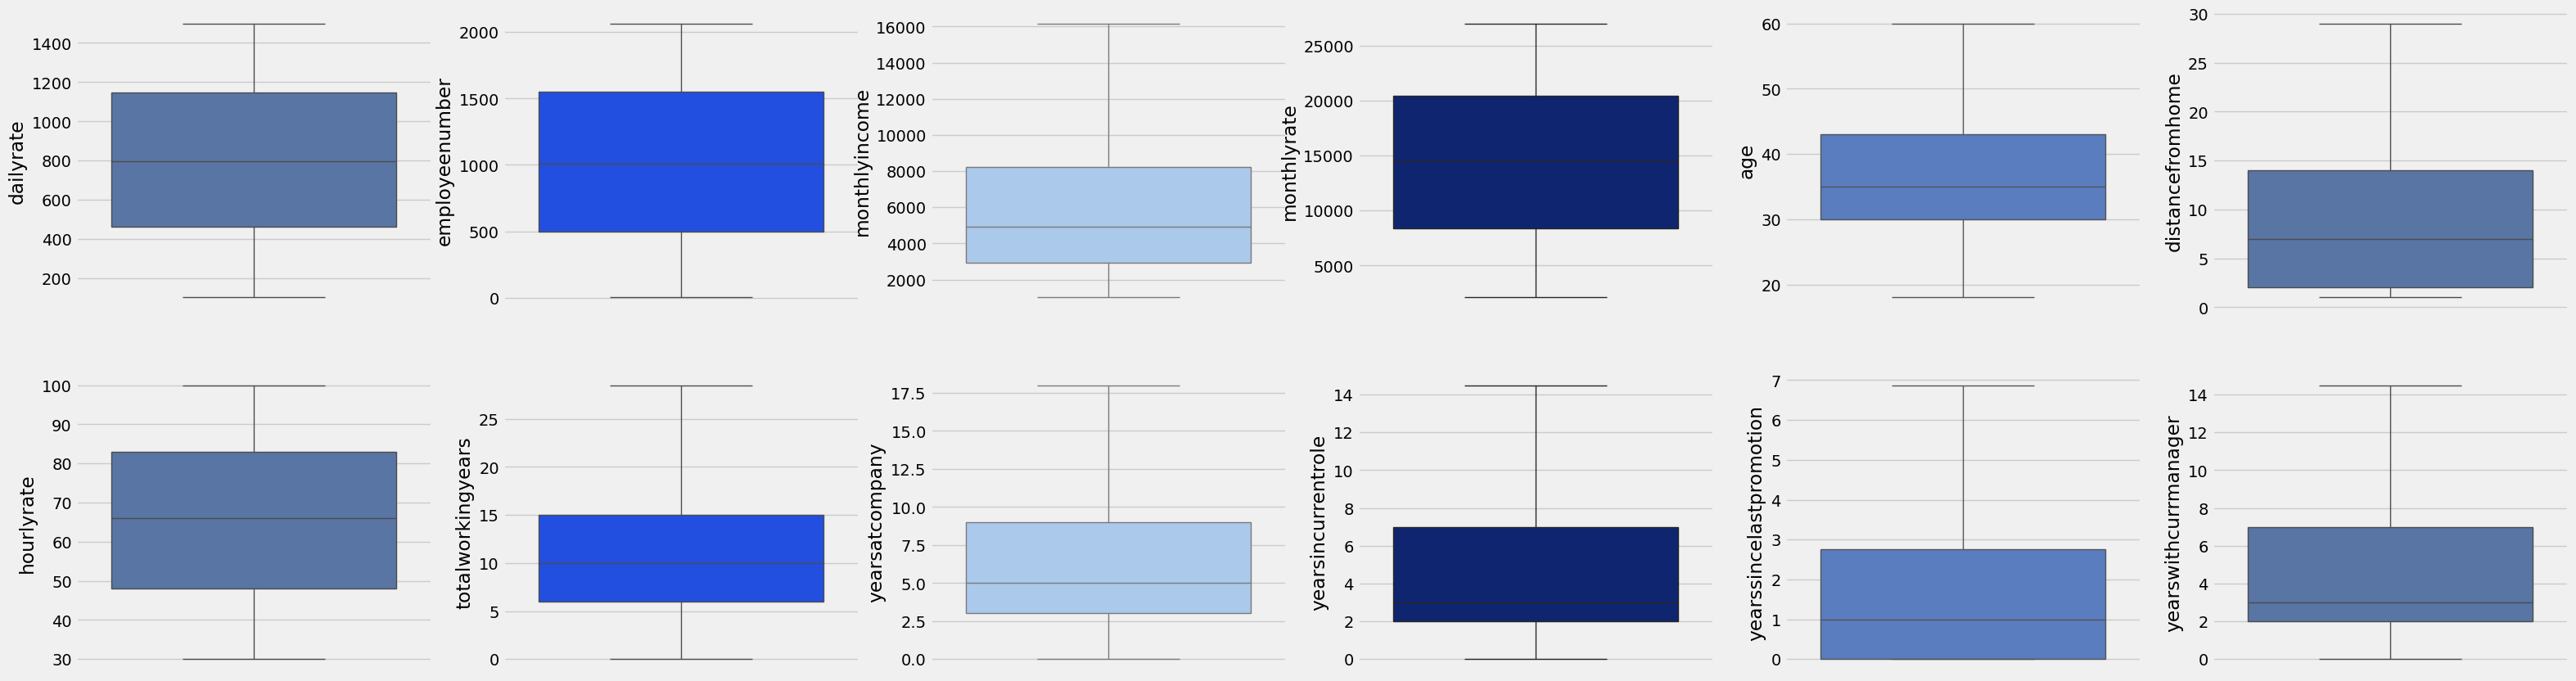

In [ ]:
# Check for outliers
# YOUR CODE HERE
plt.figure(figsize=(35, 10))
plt.subplot(2,6,1)
sns.boxplot(y = 'dailyrate', data = dfAttritionDataTrim, palette="deep")
plt.subplot(2,6,2)
sns.boxplot(y = 'employeenumber', data = dfAttritionDataTrim, palette="bright")
plt.subplot(2,6,3)
sns.boxplot(y = 'monthlyincome', data = dfAttritionDataTrim, palette="pastel")
plt.subplot(2,6,4)
sns.boxplot(y = 'monthlyrate', data = dfAttritionDataTrim, palette="dark")
plt.subplot(2,6,5)
sns.boxplot(y = 'age', data = dfAttritionDataTrim, palette="muted")
plt.subplot(2,6,6)
sns.boxplot(y = 'distancefromhome', data = dfAttritionDataTrim, palette="deep")
plt.subplot(2,6,7)
sns.boxplot(y = 'hourlyrate', data = dfAttritionDataTrim, palette="deep")
plt.subplot(2,6,8)
sns.boxplot(y = 'totalworkingyears', data = dfAttritionDataTrim, palette="bright")
plt.subplot(2,6,9)
sns.boxplot(y = 'yearsatcompany', data = dfAttritionDataTrim, palette="pastel")
plt.subplot(2,6,10)
sns.boxplot(y = 'yearsincurrentrole', data = dfAttritionDataTrim, palette="dark")
plt.subplot(2,6,11)
sns.boxplot(y = 'yearssincelastpromotion', data = dfAttritionDataTrim, palette="muted")
plt.subplot(2,6,12)
sns.boxplot(y = 'yearswithcurrmanager', data = dfAttritionDataTrim, palette="deep")
plt.show()

### Target label imbalance

**Exercise 5: Check if there is an imbalance in target label [0.5 Mark]**

**Hint:** Use value_counts()

In [ ]:
# Count of unique values in Attrition column
# YOUR CODE HERE
dfAttritionDataTrim["attrition"].value_counts()

No     981
Yes    189
Name: attrition, dtype: int64

<Axes: xlabel='attrition', ylabel='count'>

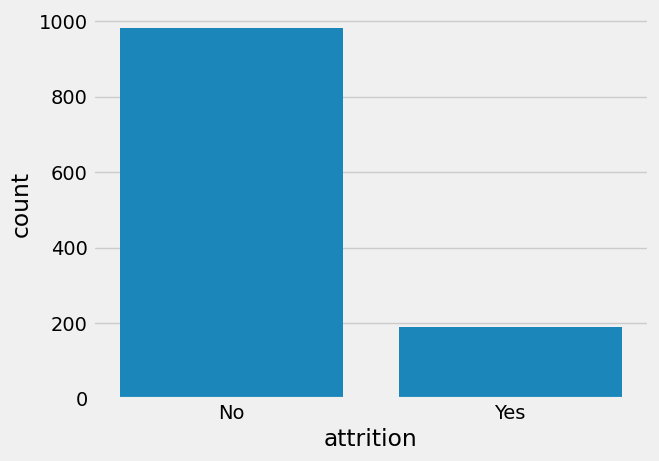

In [ ]:
# Plot barplot to visualize balance/imbalance
# YOUR CODE HERE
sns.countplot(x = 'attrition', data = dfAttritionDataTrim)

STAN TO-DO: This option portion to be done

If there is any imbalance in the dataset then a few techniques can be utilised (optional):
1. SMOTE
2. Cross Validation
3. Regularizing the model's parameters

###Plot pairplot

**Exercise 6: Visualize the relationships between the predictor variables and the target variable using a pairplot [0.5 Mark]**

**Hint:** Use sns.pairplot

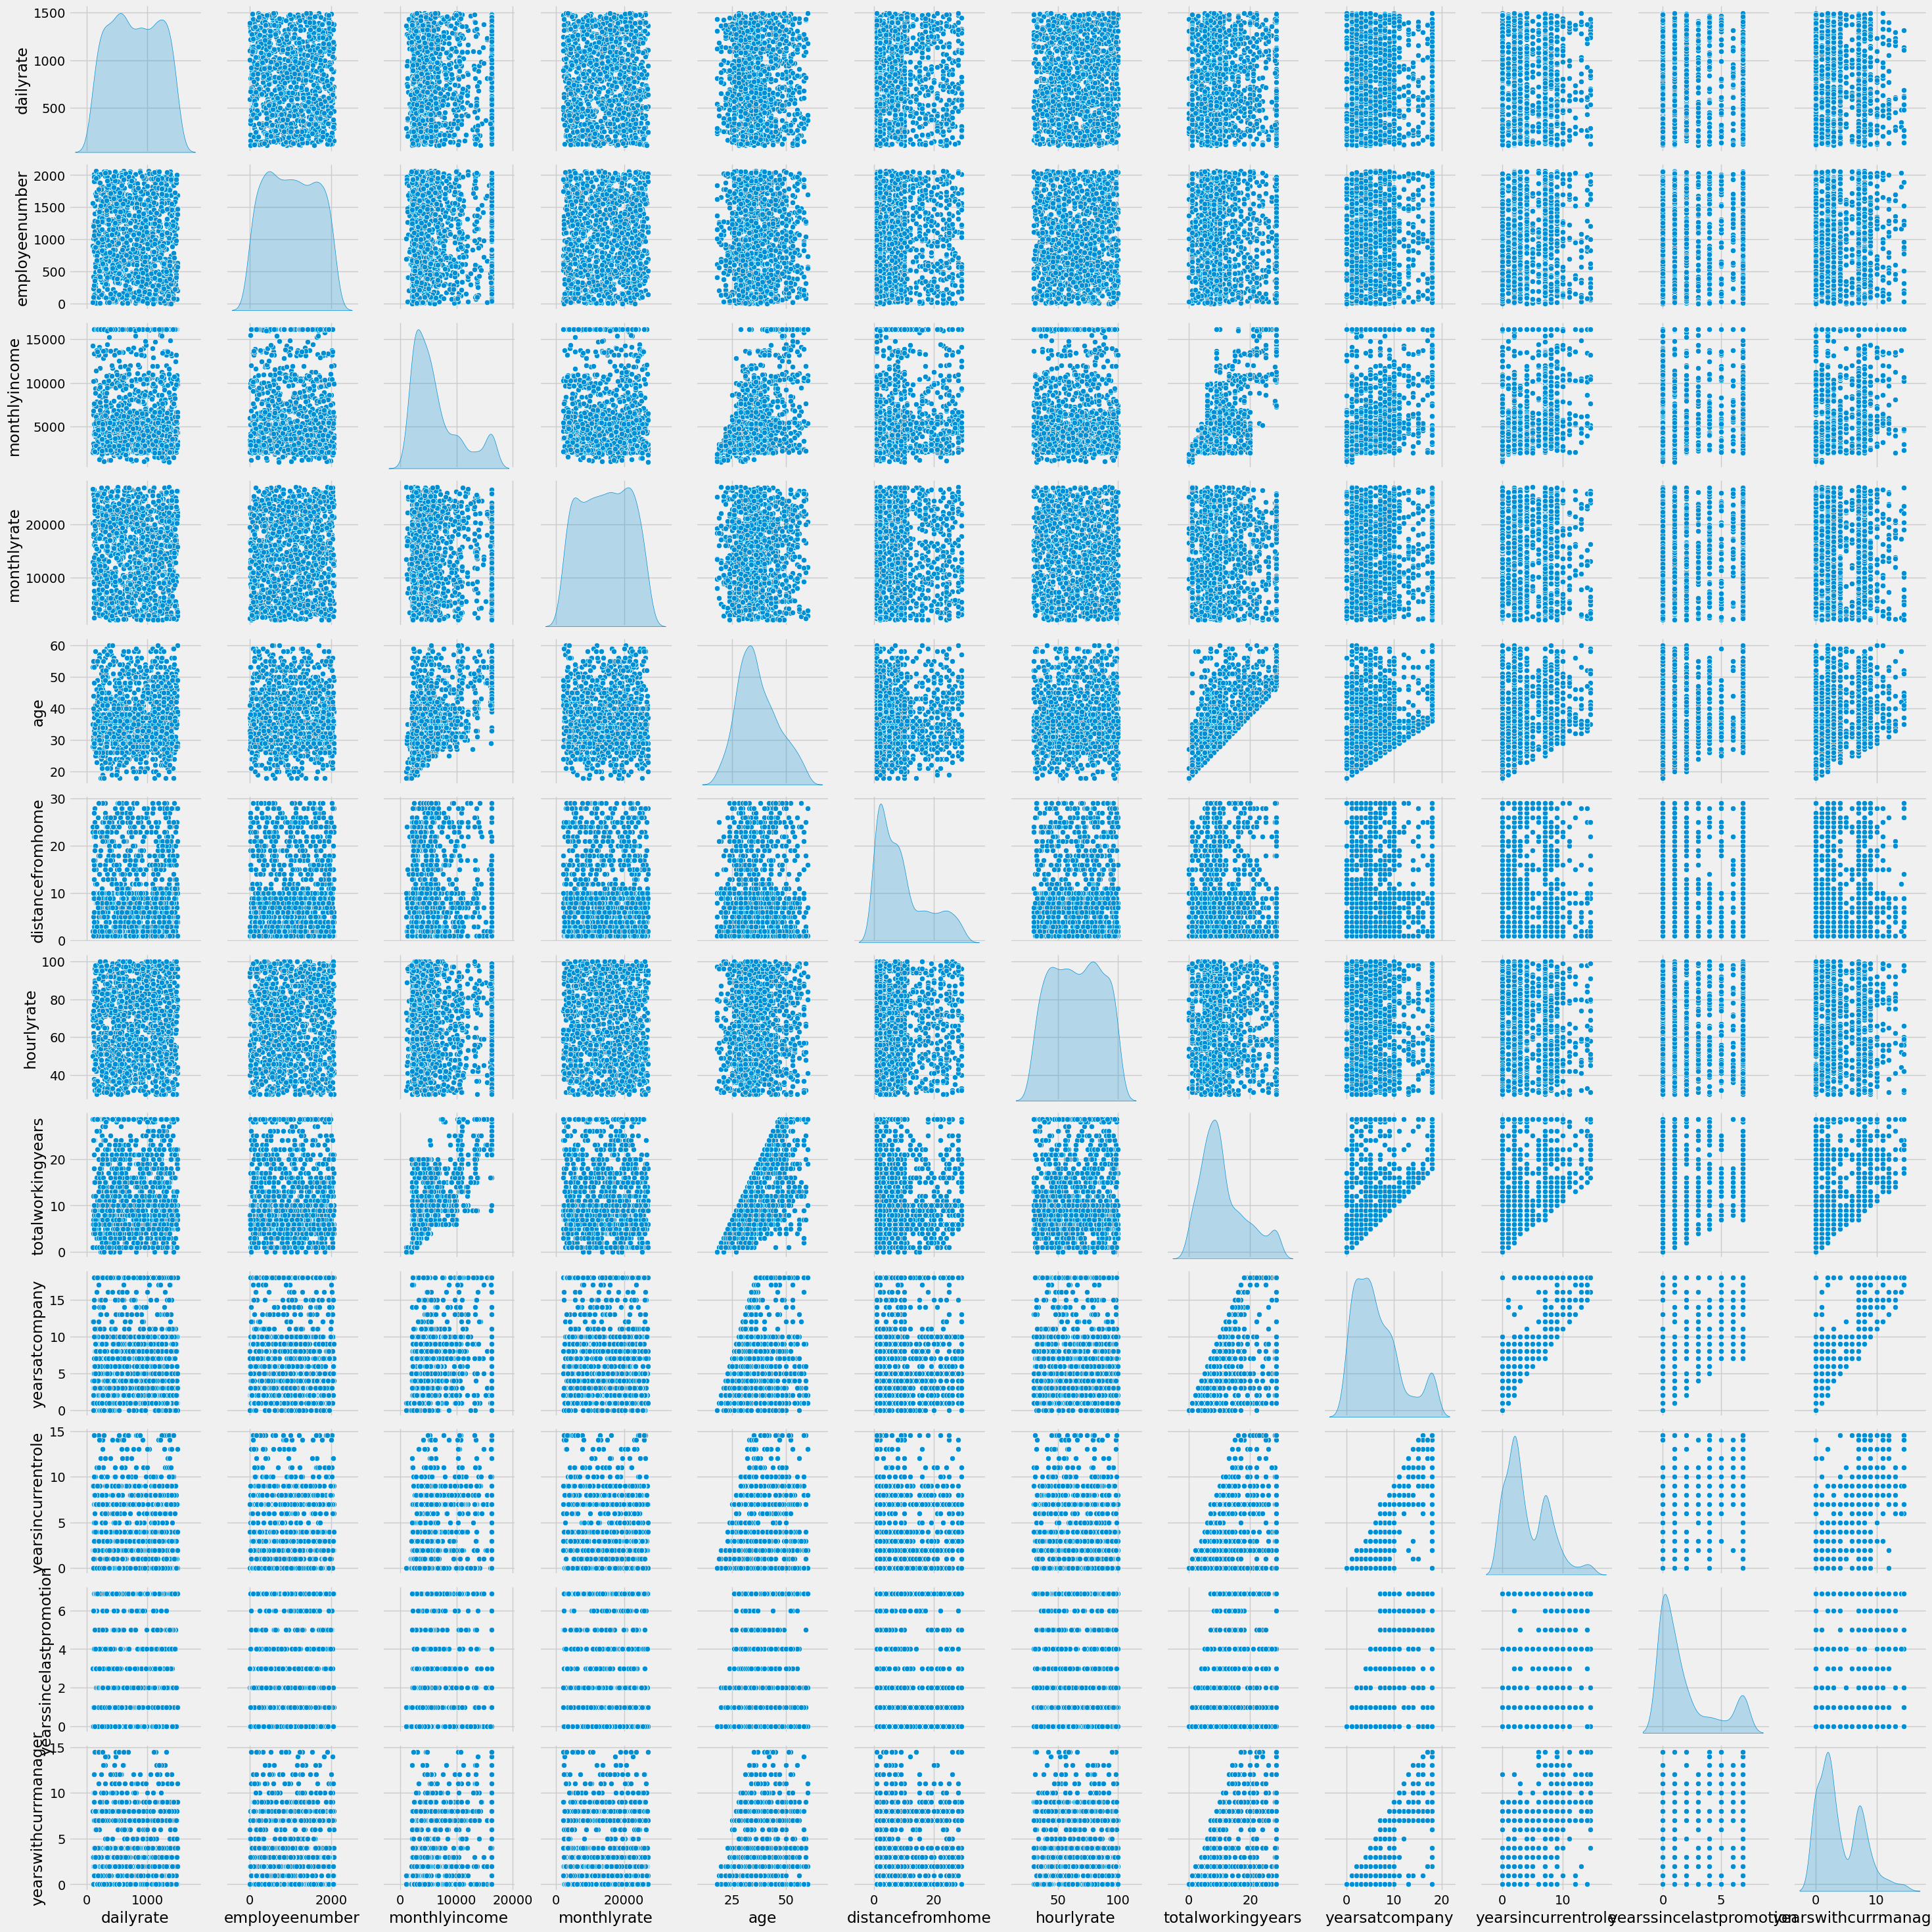

In [ ]:
# Visualize a pairplot with relevant features
# YOUR CODE HERE
dfNumerical = dfAttritionDataTrim[numericalColumns]

sns.pairplot(dfNumerical, diag_kind='kde')
plt.show()

### Explore Correlation

- Plotting the Heatmap

**Exercise 7: Visualize the correlation among IBM employee attrition numerical features using a heatmap [0.5 Mark]**

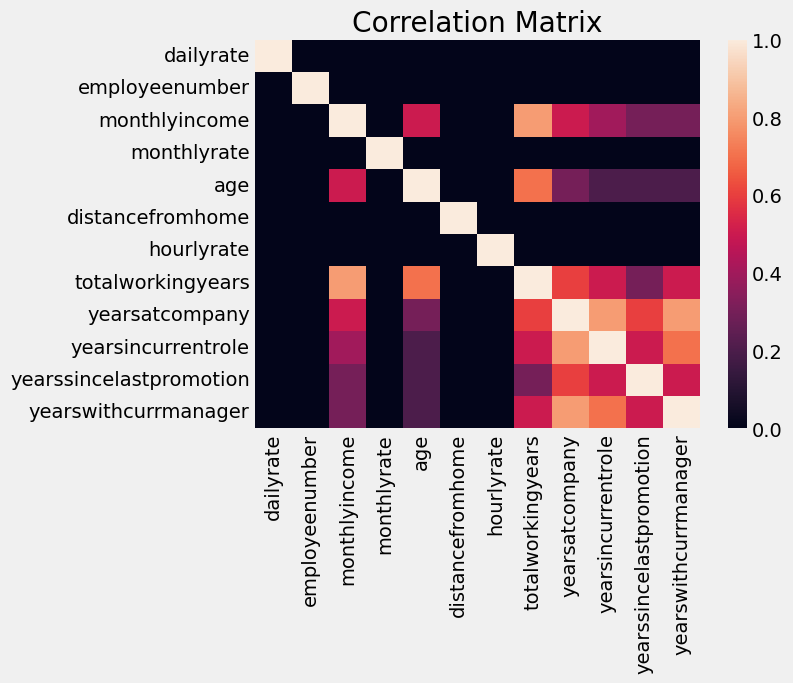

In [ ]:
# Visualize heatmap
# YOUR CODE HERE
corr_matrix = dfNumerical.corr().round(1)
corr_matrix
sns.heatmap(corr_matrix, annot=False)
plt.title('Correlation Matrix')
plt.show()

Comment on the observations made with the pairplot and heatmap

**STAN To-Do: Interpretations to be added**

### Preparing the test feature space
* Remove outliers if any
* Handle the categorical feature if required
* Other processing steps can also be followed.

In [ ]:
# YOUR CODE HERE

Optional:
Use `Hyperopt`, a hyperparameter tuning technique to identify the best set of parameters.

Refer to the Additional Notebook: CatBoost parameter tuning (CDS-B4 GDrive -> Module 2 -> Assignments -> Mar 04)

In the notebook, data processing is done separately for different models.
Considering the fact that different models may require data in different format and in turn different processes may be followed to process the data.

If the processing steps followed for the models are same, data processing can also be done once.

## Apply CatBoost

Catboost was released in 2017 by Yandex, showing, by their benchmark to be faster in prediction, better in accuracy, and easier to use for categorical data across a series of GBDT tasks. Additional capabilities of catboost include plotting feature interactions and object (row) importance.

[Here](https://catboost.ai/en/docs/) is the official documentation of CatBoost

### Data Processing for CatBoost

**Exercise 8: Data processing for CatBoost [1 Mark]**
* **Copy the dataframe that was created after removing the outliers**
* **Handle the categorical features if required**
* **Create target column and feature space**

**Hint:** Column containing the information on attrition will be the target column.

In [ ]:
dfAttritionDataTrim.head()

,age,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeenumber,environmentsatisfaction,gender,hourlyrate,jobinvolvement,joblevel,jobrole,jobsatisfaction,maritalstatus,monthlyincome,monthlyrate,numcompaniesworked,over18,overtime,percentsalaryhike,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager,attrition
0,45,Travel_Rarely,556,Research & Development,25,2,Life Sciences,1888,2,Female,93,2,2,Manufacturing Director,4,Married,5906,23888,0,Y,No,13,3,4,2,10.0,2,2,9,8.0,3.000,8.0,No
1,34,Travel_Rarely,970,Research & Development,8,2,Medical,757,2,Female,96,3,2,Healthcare Representative,3,Single,6142,7360,3,Y,No,11,3,4,0,10.0,2,3,5,1.0,4.000,3.0,No
2,39,Travel_Rarely,360,Research & Development,23,3,Medical,1310,3,Male,93,3,1,Research Scientist,1,Single,3904,22154,0,Y,No,13,3,1,0,6.0,2,3,5,2.0,0.000,3.0,Yes
3,26,Travel_Rarely,933,Sales,1,3,Life Sciences,476,3,Male,57,3,2,Sales Executive,3,Married,5296,20156,1,Y,No,17,3,2,1,8.0,3,3,8,7.0,6.875,7.0,No
4,40,Travel_Rarely,329,Research & Development,1,4,Life Sciences,1361,2,Male,88,3,1,Laboratory Technician,2,Married,2387,6762,3,Y,No,22,4,3,1,7.0,3,3,4,2.0,0.000,3.0,No


In [ ]:
#categoricalColumns.append('businesstravel') #this col was missing
categoricalColumns

['businesstravel',
 'department',
 'educationfield',
 'gender',
 'jobrole',
 'maritalstatus',
 'over18',
 'overtime',
 'attrition',
 'education',
 'environmentsatisfcation',
 'jobinvolvement',
 'joblevel',
 'jobsatisfaction',
 'numcompaniesworked',
 'percentsalaryhike',
 'performancerating',
 'relationshipsatisfaction',
 'stockoptionlevel',
 'trainingtimeslastyear',
 'worklifebalance']

In [ ]:
#encode Categorical columns using label encoder
from sklearn.preprocessing import LabelEncoder

dfAttritionDataTrim_en = dfAttritionDataTrim

label_encoder = LabelEncoder()

for column in categoricalColumns:
    dfAttritionDataTrim_en[column]= label_encoder.fit_transform(dfAttritionDataTrim_en[column])

KeyError: 'environmentsatisfcation'

In [ ]:
dfAttritionDataTrim_en.info()

In [ ]:
#Catboost
from sklearn.metrics import f1_score


y = dfAttritionDataTrim_en['attrition']
X = dfAttritionDataTrim_en.drop(['attrition'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.30, random_state= 123)

# Initialize CatBoostClassifier
model = CatBoostClassifier(iterations=1000,  # Number of trees (boosting iterations)
                           learning_rate=0.1,  # Step size shrinkage used in update to prevent overfitting
                           depth=6,  # Depth of the trees
                           loss_function='Logloss',  # Objective function
                           eval_metric='Accuracy',  # Metric for validation data
                           random_seed=42,  # Random seed for reproducibility
                           logging_level='Silent')  # Set the logging level to Silent for no output during training

# Train the model
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=100, verbose=False)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

### Model Definition

**Exercise 9: Define, train the model and display the results [2 Mark]**

**Hint:**
* Use CatBoostClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model. Refer [here](https://catboost.ai/en/docs/concepts/speed-up-training) to see some ways to speedup CatBoost training.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [ ]:
# Create CatBoost model
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

y = dfAttritionDataTrim_en['attrition']
X = dfAttritionDataTrim_en.drop(['attrition'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.30, random_state= 123)

# Initialize CatBoostClassifier
model = CatBoostClassifier(iterations=1000,  # Number of trees (boosting iterations)
                           learning_rate=0.1,  # Step size shrinkage used in update to prevent overfitting
                           depth=6,  # Depth of the trees
                           loss_function='Logloss',  # Objective function
                           eval_metric='Accuracy',  # Metric for validation data
                           random_seed=42,  # Random seed for reproducibility
                           logging_level='Silent')  # Set the logging level to Silent for no output during training

In [ ]:
# Model training
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=100, verbose=False)

### Model performance

In [ ]:
# Model performance on all sets

# Make predictions
y_pred = model.predict(X_test)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#F1 score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

#roc_auc_score
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability estimates of the positive class
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc)


## Apply XGBoost

XGBoost is a workhorse gradient boosted decision tree algorithm. Its been around since 2014 and has come to dominate the Kaggle and data science community. XGB introduced gradient boosting where new models are fit to the residuals of prior models and then added together, using a gradient descent algorithm to minimize the loss.

Read [here](https://xgboost.readthedocs.io/en/stable/parameter.html) on XGBoost parameters.

Refer [here](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier) for the official documentation of XGBoost classifier.

### Data Processing for XGBoost


**Exercise 10: Data Processing for XGBoost [1 Mark]**
* **Copy the dataframe after the outliers were removed.**
* **Handle the categorical features if required**
* **Create target column and feature space**

In [ ]:
# Copy dataframe
# YOUR CODE HERE

**Hint:** Use pd.get_dummies

In [ ]:
# Handling categorical features
# YOUR CODE HERE

In [ ]:
# Concat the dummy variables to actual dataframe and remove initial categorical columns
# YOUR CODE HERE

When creating the dummy variables, the name of attrition column was changed, rename to 'attrition' again.

**Hint:** Use .rename

In [ ]:
# Rename target column
# YOUR CODE HERE

In [ ]:
# Feature Space
# YOUR CODE HERE

# Targer label
# YOUR CODE HERE

### Model Definition

**Exercise 11: Define, train the model and display the results [2 Mark]**

**Hint:**
* Use XGBClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [ ]:
# Create XGBoost classifier model
import xgboost as xgb

# Initialize XGBoost classifier
model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

In [ ]:
# Model training
model.fit(X_train, y_train)

### Model Performance

In [ ]:
# Model performance on all sets

# Make predictions
y_pred = model.predict(X_test)

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#F1 score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

#roc_auc_score
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability estimates of the positive class
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc)

## Apply LightGBM (Optional)

LightGBM is an open-source GBDT framework created by Microsoft as a fast and scalable alternative to XGB and GBM. By default LightGBM will train a Gradient Boosted Decision Tree (GBDT), but it also supports random forests, Dropouts meet Multiple Additive Regression Trees (DART), and Gradient Based One-Side Sampling (Goss).

To know more about LightGBM parameters, refer [here](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html#lightgbm.LGBMClassifier).

### Feature Engineering for LightGBM

In [ ]:
## Following the same procedure as followed in XGBoost

# Copy the dataframe
# YOUR CODE HERE

# Handling categorical features
# YOUR CODE HERE

# Concat the dummy variables to actual dataframe and remove initial categorical columns
# YOUR CODE HERE

# Rename target column
# YOUR CODE HERE

# Features Space
# YOUR CODE HERE

# Target Label
# YOUR CODE HERE

### Model Definition

**Hint:**
* Use LGBMClassifier() to define the model with relevant parameters.
* Use `fit` to fit the data to the model.
* Evaluate the model using roc_auc_score, accuracy_score, f1_score, predict methods or other relevant techniques.

In [ ]:
# Create LightGBM classifier model
# YOUR CODE HERE
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

# Set hyperparameters
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

In [ ]:
# Model training

num_round = 100
bst = lgb.train(params, train_data, num_round, valid_sets=[test_data], early_stopping_rounds=10, verbose_eval=False)


### Model performance

In [ ]:
# Model performance on all sets
y_pred_proba = bst.predict(X_test, num_iteration=bst.best_iteration)
y_pred = [1 if pred > 0.5 else 0 for pred in y_pred_proba]

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#F1 score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

#roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", roc_auc)

## Results

**Exercise 12: Create a dataframe of XGBoost results and CatBoost results and display them [0.5 Mark]**

**Hint:** Use pd.DataFrame

In [ ]:
# Create a dataframe for computed metrics for different models
# YOUR CODE HERE

Reference reading:
1. https://machinelearningmastery.com/xgboost-for-imbalanced-classification/